# MarketLens Stage 2: Fetch API Data

This notebook downloads raw market and macroeconomic data.

Outputs:
- `data/raw/spy_prices.csv`
- `data/raw/dgs10_yield.csv`

Data sources:
- SPY price data from Yahoo Finance through `yfinance`
- DGS10 10-Year Treasury yield from FRED API

#### Imports and project root

In [1]:
from pathlib import Path
import os
import requests
import pandas as pd
import yfinance as yf
from dotenv import load_dotenv
from getpass import getpass

PROJECT_ROOT = Path(r"C:\Users\Wilson\Documents\OpenAI\MarketLens")
os.chdir(PROJECT_ROOT)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(Path.cwd())

print("\nRaw data folder:")
print(RAW_DIR)

Current working directory:
C:\Users\Wilson\Documents\OpenAI\MarketLens

Raw data folder:
C:\Users\Wilson\Documents\OpenAI\MarketLens\data\raw


#### Load FRED API key

In [2]:
load_dotenv()

fred_key = os.getenv("FRED_API_KEY")

if not fred_key or fred_key == "PASTE_YOUR_FRED_KEY_HERE":
    fred_key = getpass("Paste your FRED API key: ").strip()
    os.environ["FRED_API_KEY"] = fred_key

print("FRED API key loaded.")

FRED API key loaded.


#### Fetch SPY data with yfinance

In [3]:
ticker = "SPY"
start_date = "2018-01-01"

spy = yf.download(
    ticker,
    start=start_date,
    progress=False,
    auto_adjust=False
)

if spy.empty:
    raise ValueError("No SPY data returned from yfinance.")

# Handle possible MultiIndex columns from yfinance
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy.reset_index()

# Standardize column names
spy.columns = [str(col).lower().replace(" ", "_") for col in spy.columns]

# Keep required columns only
required_cols = ["date", "open", "high", "low", "close", "adj_close", "volume"]
available_cols = [col for col in required_cols if col in spy.columns]
spy = spy[available_cols]

spy_path = RAW_DIR / "spy_prices.csv"
spy.to_csv(spy_path, index=False)

print(f"Saved SPY data to: {spy_path}")
print(f"Rows: {len(spy)}")
spy.head()

Saved SPY data to: C:\Users\Wilson\Documents\OpenAI\MarketLens\data\raw\spy_prices.csv
Rows: 2136


,date,open,high,low,close,adj_close,volume
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200


#### yfinance fallback using Stooq only if Cell 4 fails

In [ ]:
stooq_url = "https://stooq.com/q/d/l/?s=spy.us&i=d"

spy = pd.read_csv(stooq_url)

if spy.empty:
    raise ValueError("No SPY data returned from Stooq.")

spy.columns = [str(col).lower().replace(" ", "_") for col in spy.columns]

# Stooq column names usually come as: date, open, high, low, close, volume
spy["date"] = pd.to_datetime(spy["date"])
spy = spy[spy["date"] >= start_date]

spy_path = RAW_DIR / "spy_prices.csv"
spy.to_csv(spy_path, index=False)

print(f"Saved SPY data from Stooq fallback to: {spy_path}")
print(f"Rows: {len(spy)}")
spy.head()

#### Fetch DGS10 data from FRED API

In [4]:
fred_key = os.getenv("FRED_API_KEY")

params = {
    "series_id": "DGS10",
    "api_key": fred_key,
    "file_type": "json",
    "observation_start": start_date,
}

url = "https://api.stlouisfed.org/fred/series/observations"

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

data = response.json()

if "observations" not in data:
    raise ValueError("FRED response does not contain observations.")

dgs10 = pd.DataFrame(data["observations"])

if dgs10.empty:
    raise ValueError("No DGS10 data returned from FRED.")

dgs10 = dgs10[["date", "value"]].copy()
dgs10["date"] = pd.to_datetime(dgs10["date"])
dgs10["value"] = pd.to_numeric(dgs10["value"], errors="coerce")
dgs10 = dgs10.rename(columns={"value": "dgs10"})

dgs10_path = RAW_DIR / "dgs10_yield.csv"
dgs10.to_csv(dgs10_path, index=False)

print(f"Saved DGS10 data to: {dgs10_path}")
print(f"Rows: {len(dgs10)}")
dgs10.head()

Saved DGS10 data to: C:\Users\Wilson\Documents\OpenAI\MarketLens\data\raw\dgs10_yield.csv
Rows: 2218


,date,dgs10
0,2018-01-01,NaN
1,2018-01-02,2.46
2,2018-01-03,2.44
3,2018-01-04,2.46
4,2018-01-05,2.47


#### Verify saved files

In [5]:
files_to_check = [
    RAW_DIR / "spy_prices.csv",
    RAW_DIR / "dgs10_yield.csv",
]

for file_path in files_to_check:
    if file_path.exists():
        df = pd.read_csv(file_path)
        print(f"{file_path.name}: OK | rows={len(df)} | columns={list(df.columns)}")
    else:
        print(f"{file_path.name}: MISSING")

spy_prices.csv: OK | rows=2136 | columns=['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']
dgs10_yield.csv: OK | rows=2218 | columns=['date', 'dgs10']


#### Quick visual check

Text(0, 0.5, 'Close Price')

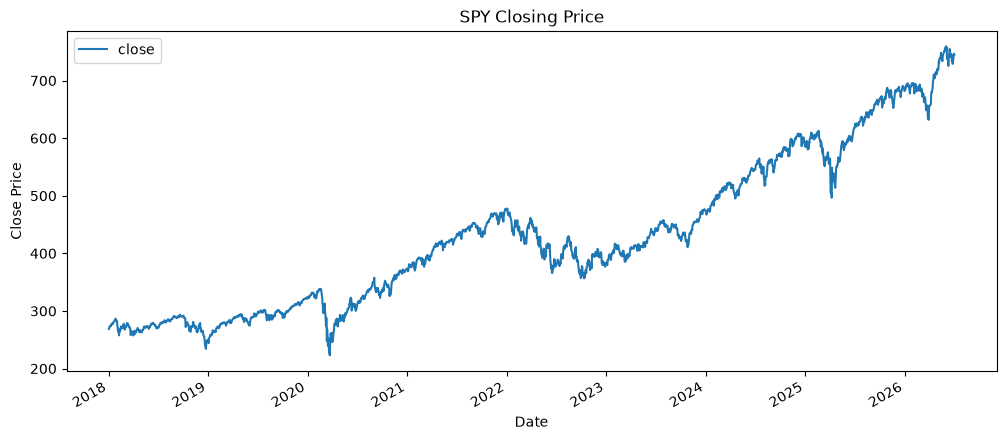

In [6]:
spy_check = pd.read_csv(RAW_DIR / "spy_prices.csv")
dgs10_check = pd.read_csv(RAW_DIR / "dgs10_yield.csv")

spy_check["date"] = pd.to_datetime(spy_check["date"])
dgs10_check["date"] = pd.to_datetime(dgs10_check["date"])

ax = spy_check.plot(x="date", y="close", figsize=(12, 5), title="SPY Closing Price")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")

#### Save fetch report

In [7]:
from datetime import datetime

report_path = PROJECT_ROOT / "reports" / "data_fetch_check.txt"

report = f"""
MarketLens Data Fetch Check

Status: Raw data fetch completed.
Timestamp: {datetime.now()}

Files created:
- data/raw/spy_prices.csv
- data/raw/dgs10_yield.csv

SPY rows: {len(pd.read_csv(RAW_DIR / "spy_prices.csv"))}
DGS10 rows: {len(pd.read_csv(RAW_DIR / "dgs10_yield.csv"))}

Notes:
- SPY data was fetched using yfinance unless fallback was used.
- DGS10 data was fetched using the FRED API.
- This dataset is for educational and portfolio demonstration only.
"""

report_path.write_text(report.strip(), encoding="utf-8")

print(f"Report saved to: {report_path}")

Report saved to: C:\Users\Wilson\Documents\OpenAI\MarketLens\reports\data_fetch_check.txt
